# 04 — Tiling and the Area API

The Area API does the boring work for you:

1. Splits a polygon into 512 m inference tiles.
2. Fetches buildings / vegetation / ground materials per tile,
   with the right context margin for each analysis family.
3. Submits one async job per tile, in parallel.
4. Waits for results, blends and clips them back to the original polygon.

This notebook covers:

- `client.preview_area(polygon)` -- preview cost without spending tokens
- the difference between a 1-tile rectangle and a multi-tile irregular polygon
- how to inspect the tile grid produced by the SDK
- the fields on the returned `AreaResult`

In [1]:
from dotenv import load_dotenv
load_dotenv()

from infrared_sdk import InfraredClient
from infrared_sdk.analyses.types import AnalysesName, WindModelRequest
from cities import get

city = get("munich")

## 1. Preview a small rectangular polygon

`preview_area` returns the tile count, an estimated wall-clock time,
and an estimated token cost. No jobs are submitted.

In [2]:
with InfraredClient() as client:
    pv_small = client.preview_area(city.polygon_small)
print(f"polygon_small  : {pv_small.tile_count} tile(s), "
      f"~{pv_small.estimated_time_s:.0f}s, ~{pv_small.estimated_cost_tokens} tokens")

polygon_small  : 1 tile(s), ~10s, ~10 tokens


## 2. Preview the irregular pentagon

`cities.City.polygon_large` is an asymmetric pentagon ~1.2 km wide. It
deliberately straddles tile boundaries so you'll see 4-6 non-empty tiles.

In [3]:
with InfraredClient() as client:
    pv_large = client.preview_area(city.polygon_large)
print(f"polygon_large  : {pv_large.tile_count} tile(s), "
      f"~{pv_large.estimated_time_s:.0f}s, ~{pv_large.estimated_cost_tokens} tokens")

polygon_large  : 25 tile(s), ~250s, ~250 tokens


## 3. Visualise both polygons and the inferred tile grids

Use the SDK's internal tiler to compute the tile grid (handy for
inspection). The tile grid is computed in **meter space** relative to
the polygon bbox SW corner.

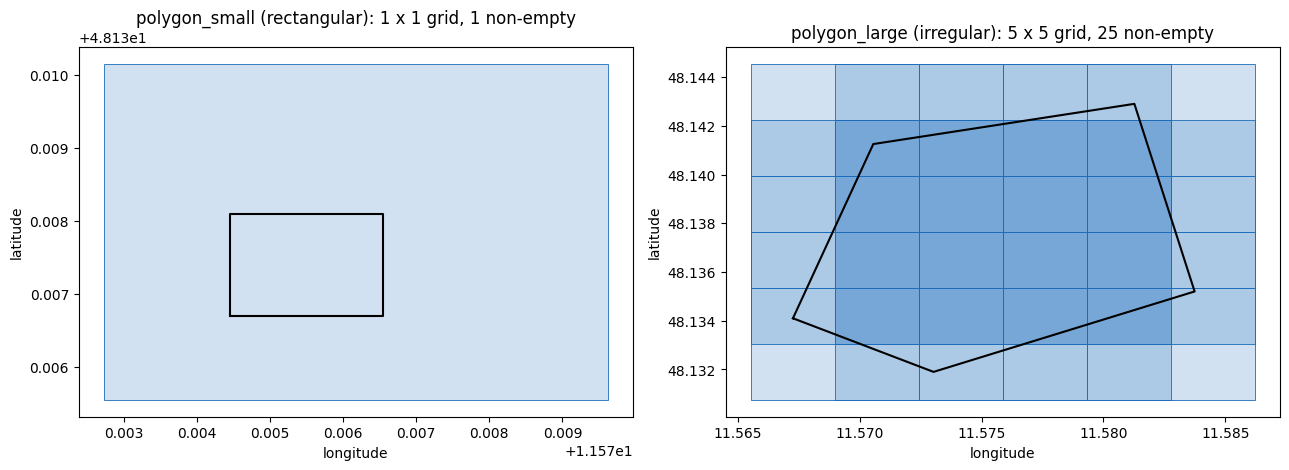

In [4]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

with InfraredClient() as client:
    grid_small = client._generate_tiles(city.polygon_small,
                                        analysis_type=str(AnalysesName.wind_speed))
    grid_large = client._generate_tiles(city.polygon_large,
                                        analysis_type=str(AnalysesName.wind_speed))

def tile_bbox_lonlat(tile):
    """Convert (centroid, size_meters) -> (lon_min, lat_min, lon_max, lat_max)."""
    cx, cy = tile.centroid.longitude, tile.centroid.latitude
    dlat = (tile.size.y / 2) / 111_320.0
    dlon = (tile.size.x / 2) / (111_320.0 * math.cos(math.radians(cy)))
    return cx - dlon, cy - dlat, cx + dlon, cy + dlat

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, grid, poly, title in [
    (axes[0], grid_small, city.polygon_small, "polygon_small (rectangular)"),
    (axes[1], grid_large, city.polygon_large, "polygon_large (irregular)"),
]:
    coords = poly["coordinates"][0]
    ax.plot([p[0] for p in coords], [p[1] for p in coords], "k-", lw=1.5)
    for row in grid.tiles:
        for tile in row:
            x0, y0, x1, y1 = tile_bbox_lonlat(tile)
            color = "#1b6cba33" if not tile.empty else "#cccccc44"
            edge  = "#1b6cba"   if not tile.empty else "#bbbbbb"
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                   facecolor=color, edgecolor=edge, lw=0.6))
    ax.set_aspect("equal")
    ax.set_title(f"{title}: {grid.num_rows} x {grid.num_cols} grid, "
                 f"{len(grid.non_empty_tiles)} non-empty")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.tight_layout(); plt.show()

Filled blue tiles are non-empty (will get a job submitted).
Light-grey tiles are skipped because no part of them overlaps the
polygon. The Area API only spends tokens on filled tiles.

## 4. Run an analysis on the irregular polygon

Pick wind because it's cheap and doesn't need weather. The SDK
fetches buildings, splits them into per-tile chunks, submits 4-6 jobs
in parallel, and merges the results back to a single grid.

In [5]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_large)
    [result] = client.run_area_and_wait(
        [WindModelRequest(
            analysis_type=AnalysesName.wind_speed,
            wind_speed=5, wind_direction=270,
        )],
        city.polygon_large,
        buildings=area.buildings,
    )

import numpy as np
valid = result.merged_grid[~np.isnan(result.merged_grid)]
print(f"merged grid shape : {result.grid_shape}")
print(f"jobs              : {result.succeeded_jobs}/{result.total_jobs}")
print(f"value range       : [{float(valid.min()):.2f}, {float(valid.max()):.2f}] m/s")

merged grid shape : (1280, 1280)
jobs              : 25/25
value range       : [0.00, 7.76] m/s


## 5. Inspect the merged grid

The merged grid spans the **bounding box** of the polygon, with `NaN`
outside the polygon shape. Its rows go south->north (row 0 = south).

cells total   : 1638400
cells valid   : 485154  (29.6%)
cells nan     : 1153246  (outside polygon)


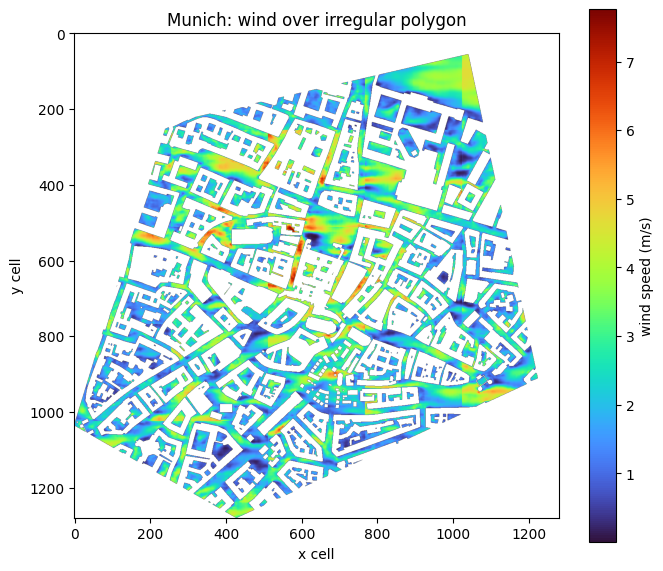

In [6]:
import numpy as np

valid = result.merged_grid[~np.isnan(result.merged_grid)]
print(f"cells total   : {result.merged_grid.size}")
print(f"cells valid   : {valid.size}  ({100*valid.size/result.merged_grid.size:.1f}%)")
print(f"cells nan     : {result.merged_grid.size - valid.size}  (outside polygon)")

plt.figure(figsize=(7, 6))
plt.imshow(np.flipud(result.merged_grid), cmap="turbo",
           vmin=result.min_legend, vmax=result.max_legend)
plt.colorbar(label="wind speed (m/s)")
plt.title(f"{city.name}: wind over irregular polygon")
plt.xlabel("x cell"); plt.ylabel("y cell")
plt.tight_layout(); plt.show()

## AreaResult fields

```python
result.merged_grid       # numpy ndarray, NaN outside polygon
result.polygon           # the input polygon (echoed back)
result.analysis_type     # e.g. "wind-speed"
result.grid_shape        # (rows, cols)
result.failed_jobs       # list of job IDs that failed
result.skipped_jobs      # list of job IDs not yet merged
result.total_jobs        # tile count
result.succeeded_jobs    # tile count - failed - skipped
result.min_legend        # API-suggested colormap lower bound
result.max_legend        # API-suggested colormap upper bound
```

Persist with `result.to_dict()` and reload with `AreaResult.from_dict(d)`.

Next: `05_analysis_types_tour.ipynb` walks through the full payload
catalogue.